<a href="https://colab.research.google.com/github/Megha066/image_recognition/blob/main/Image_DeepfakeDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### importing modules

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from datasets import load_dataset, DatasetDict
from sklearn.model_selection import StratifiedKFold

loading dataset from Hugging face

In [ ]:
dataset = load_dataset("Hemg/deepfake-and-real-images")
print(dataset.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


{'train': (190335, 2)}


counting no of immages under each label

In [ ]:
from collections import Counter

label_counts = Counter(dataset["train"]["label"])
print(label_counts)

Counter({1: 95201, 0: 95134})


In [ ]:
subset_size = 80000   # change based on your laptop

small_dataset = dataset["train"].shuffle(seed=42).select(range(subset_size))

In [ ]:
# images = list(small_dataset["image"])
labels = list(small_dataset["label"])
# print(type(images))

In [ ]:
# k=5

# skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

In [ ]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(skf.split(range(len(labels)), labels)):

    print(f"Fold {fold+1}")

    train_split = small_dataset.select(train_idx)
    val_split   = small_dataset.select(val_idx)

Fold 1
Fold 2
Fold 3
Fold 4
Fold 5


In [ ]:
train_ds = train_split.to_tf_dataset(
    columns=["image"],
    label_cols=["label"],
    batch_size=32,
    shuffle=True
)

val_ds = val_split.to_tf_dataset(
    columns=["image"],
    label_cols=["label"],
    batch_size=32,
    shuffle=False
)

/usr/local/lib/python3.12/dist-packages/datasets/arrow_dataset.py:403: FutureWarning: The output of `to_tf_dataset` will change when a passing single element list for `labels` or `columns` in the next datasets version. To return a tuple structure rather than dict, pass a single string.
Old behaviour: columns=['a'], labels=['labels'] -> (tf.Tensor, tf.Tensor)  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor)  
New behaviour: columns=['a'],labels=['labels'] -> ({'a': tf.Tensor}, {'labels': tf.Tensor})  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor) 
  warnings.warn(


In [ ]:
def preprocess(x, y):
    x = tf.image.resize(x, (224, 224))
    y = tf.cast(y, tf.float32)
    return x, y

train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

### **selecting a subset of the entire dataset **
      

In [ ]:


# Split the dataset into train (80%) and test+validation (20%)
train_test_split = small_dataset.train_test_split(test_size=0.2, seed=42)
# Further split the test+validation into test (10%) and validation (10%)
test_validation_split = train_test_split['test'].train_test_split(test_size=0.5, seed=42)
# Combine all splits into a single DatasetDict
dataset_splits = DatasetDict({
   'train': train_test_split['train'],
   'test': test_validation_split['test'],
   'validation': test_validation_split['train']
})
print(dataset_splits)

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 64000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 8000
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 8000
    })
})


In [ ]:
from collections import Counter

label_counts = Counter(small_dataset["label"])
print(label_counts)

In [ ]:
# dataset_splits.set_format(type="tensorflow", columns=["image", "label"])

splitting train-validation-test in ration [80-10-10]


In [ ]:
import tensorflow as tf
# IMG_SIZE=(224,224)

batch_size = 32 # Define batch_size here to use in to_tf_dataset

train_ds = dataset_splits["train"].to_tf_dataset(
    columns=["image"],
    label_cols="label", # Changed to string for simpler tuple output structure
    # Removed batch_size here to process individual samples first
    shuffle=True
)

valid_ds = dataset_splits["validation"].to_tf_dataset(
    columns=["image"],
    label_cols="label", # Changed to string for simpler tuple output structure
    # Removed batch_size here to process individual samples first
    shuffle=True
)



In [ ]:
test_ds = dataset_splits["test"].to_tf_dataset(
    columns=["image"],
    label_cols="label", # Changed to string for simpler tuple output structure
    # Removed batch_size here to process individual samples first
    shuffle=True
)

no of samples

In [ ]:
print(f"Number of training samples: {train_ds.cardinality()}")
print(f"Number of validation samples: {valid_ds.cardinality()}")
print(f"Number of test samples: {test_ds.cardinality()}")

Number of training samples: 64000
Number of validation samples: 8000
Number of test samples: 8000


## resizing and rescaling

In [ ]:
resize_fn=keras.layers.Resizing(224,224)

# IMG_SIZE = 224

# resize = keras.Sequential([
#   layers.Resizing(IMG_SIZE, IMG_SIZE),
#   # layers.Rescaling(1./255)
# ])

train_ds = train_ds.map(lambda x, y: (resize_fn(x), y))
valid_ds = valid_ds.map(lambda x, y: (resize_fn(x), y))
test_ds = test_ds.map(lambda x, y: (resize_fn(x), y))

# visualizing the input image

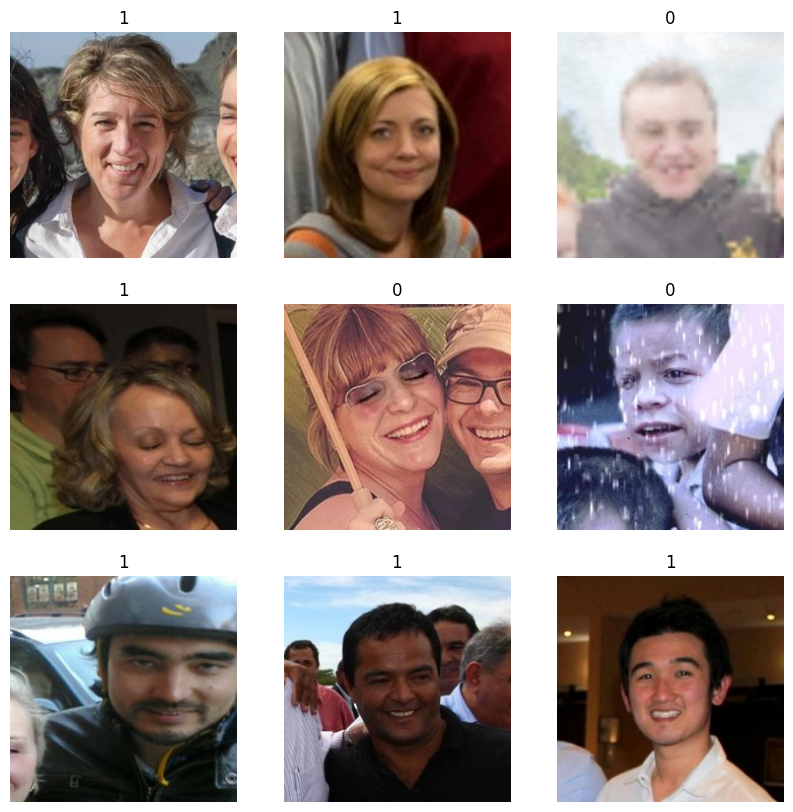

In [ ]:
plt.figure(figsize=(10, 10))

# Iterate directly over the dataset to get individual image and label tensors
for i, (image_tensor, label_tensor) in enumerate(train_ds.take(9)): # Display the first 9 images
    ax = plt.subplot(3, 3, i + 1)
    # Convert tensor to numpy array and ensure correct dtype for display
    single_image = image_tensor.numpy().astype("uint8")
    single_label = label_tensor.numpy()

    plt.imshow(single_image)
    plt.title(int(single_label))
    plt.axis("off")

# data Augmentation

In [ ]:
# augmentation_layers = [
#     layers.RandomFlip("horizontal"),
#     layers.RandomRotation(0.2),
# ]


# def data_augmentation(x):
#     for layer in augmentation_layers:
#         x = layer(x)
#     return x
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
])

# train_ds = train_ds.map(lambda x, y: (data_augmentation(x), y))


# Batching and making labels to float req for BinaryCrossEntropy

In [ ]:
from tensorflow import data as tf_data

batch_size = 32

# Ensure labels are float32 for BinaryCrossentropy
train_ds = train_ds.map(lambda x, y: (x, tf.cast(y, tf.float32))).batch(batch_size).prefetch(tf_data.AUTOTUNE)#.cache()
valid_ds = valid_ds.map(lambda x, y: (x, tf.cast(y, tf.float32))).batch(batch_size).prefetch(tf_data.AUTOTUNE)#.cache()
test_ds = test_ds.map(lambda x, y: (x, tf.cast(y, tf.float32))).batch(batch_size).prefetch(tf_data.AUTOTUNE)#.cache()

In [ ]:
valid_ds

# visualising single Augmented image

In [ ]:
# for images, labels in train_ds.take(1):
#     plt.figure(figsize=(10, 10))
#     first_image = images[0]
#     for i in range(9):
#         ax = plt.subplot(3, 3, i + 1)
#         augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
#         plt.imshow(np.array(augmented_image[0]).astype("int32"))
#         plt.title(int(labels[0]))
#         plt.axis("off")


In [ ]:
xception_model = keras.applications.Xception(
    weights="imagenet",  # Load weights pre-trained on ImageNet.
    input_shape=(224, 224, 3),
    include_top=False,
)  # Do not include the ImageNet classifier at the top.

# Freeze the base_model
xception_model.trainable = False

# Create new model on top
inputs = keras.Input(shape=(224, 224, 3))

# Pre-trained Xception weights requires that input be scaled
# from (0, 255) to a range of (-1., +1.), the rescaling layer
# outputs: `(inputs * scale) + offset`
x=data_augmentation(inputs)
x = keras.layers.Rescaling(scale=1 / 127.5, offset=-1)(inputs)

# The base model contains batchnorm layers. We want to keep them in inference mode
# when we unfreeze the base model for fine-tuning, so we make sure that the
# base_model is running in inference mode here.
x = xception_model(x, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dropout(0.2)(x)  # Regularize with dropout
outputs = keras.layers.Dense(1)(x)
model1 = keras.Model(inputs, outputs)

model1.summary(show_trainable=True)

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1 (InputLayer)  │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ rescaling (Rescaling)       │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ xception (Functional)       │ (None, 7, 7, 2048)    │ 20,861,480 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 2048)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 2048)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 1)             │      2,049 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 20,863,529 (79.59 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 20,861,480 (79.58 MB)

In [ ]:
model1.compile(
    optimizer = keras.optimizers.Adam(),
    loss= keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=[keras.metrics.BinaryAccuracy()]
)

In [ ]:
epochs = 5
print("Fitting the top layer of the model")
model1.fit(train_ds, epochs=epochs, validation_data=valid_ds)

Fitting the top layer of the model
Epoch 1/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 625s 307ms/step - binary_accuracy: 0.7116 - loss: 0.5300 - val_binary_accuracy: 0.7520 - val_loss: 0.4974
Epoch 2/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 602s 301ms/step - binary_accuracy: 0.7355 - loss: 0.5035 - val_binary_accuracy: 0.7591 - val_loss: 0.4874
Epoch 3/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 601s 300ms/step - binary_accuracy: 0.7394 - loss: 0.4970 - val_binary_accuracy: 0.7544 - val_loss: 0.4832
Epoch 4/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 602s 301ms/step - binary_accuracy: 0.7413 - loss: 0.4974 - val_binary_accuracy: 0.7541 - val_loss: 0.4852
Epoch 5/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 600s 300ms/step - binary_accuracy: 0.7407 - loss: 0.4954 - val_binary_accuracy: 0.7476 - val_loss: 0.4804


In [ ]:
# Unfreeze the base_model. Note that it keeps running in inference mode
# since we passed `training=False` when calling it. This means that
# the batchnorm layers will not update their batch statistics.
# This prevents the batchnorm layers from undoing all the training
# we've done so far.
xception_model.trainable = True
model1.summary(show_trainable=True)

model1.compile(
    optimizer=keras.optimizers.Adam(1e-5),  # Low learning rate
    loss=keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=[keras.metrics.BinaryAccuracy()],
)

epochs = 3
print("Fitting the end-to-end model")
model1.fit(train_ds, epochs=epochs, validation_data=valid_ds)


In [ ]:
print("Test dataset evaluation")
model1.evaluate(test_ds)

Test dataset evaluation
250/250 ━━━━━━━━━━━━━━━━━━━━ 66s 264ms/step - binary_accuracy: 0.7426 - loss: 0.4782


[0.47820866107940674, 0.7426249980926514]

In [ ]:
model1.evaluate(valid_ds)

250/250 ━━━━━━━━━━━━━━━━━━━━ 66s 264ms/step - binary_accuracy: 0.7476 - loss: 0.4804


[0.48040565848350525, 0.7476249933242798]

In [ ]:
# inputs = keras.Input(shape=(150, 150, 3))

# # Add a rescaling layer to normalize inputs from [0, 255] to [0, 1]
# x = keras.layers.Rescaling(1./255)(inputs) # Scale to [0, 1]

# # Instantiate the base EfficientNetB0 model
# efficientnetb0_model = EfficientNetB0(
#     include_top=False, # We will add our own top layer
#     weights=None,      # Training from scratch
#     input_shape=(150, 150, 3), # Input shape for the EfficientNet base
# )

# # Connect the base model to the scaled inputs
# x = efficientnetb0_model(x, training=True) # training=True since weights=None

# x = keras.layers.GlobalAveragePooling2D()(x)
# x = keras.layers.Dropout(0.2)(x) # Add a dropout layer for regularization
# outputs = keras.layers.Dense(1)(x) # Output layer for 1 class for binary classification

# model2 = keras.Model(inputs, outputs)

# model2.compile(optimizer = keras.optimizers.Adam(),
#     loss= keras.losses.BinaryCrossentropy(from_logits=True),
#     metrics=[keras.metrics.BinaryAccuracy()])

# model2.summary()

# epochs = 10
# hist = model2.fit(train_ds, epochs=epochs, validation_data=valid_ds)

In [ ]:
# print("Test dataset evaluation")
# model2.evaluate(test_ds)



In [ ]:
# print("validaton dataset evaluation")
# model2.evaluate(valid_ds)

In [ ]:
# inputs = keras.Input(shape=(150, 150, 3))

# # Add a rescaling layer to normalize inputs from [0, 255] to [0, 1]
# x = keras.layers.Rescaling(1./255)(inputs) # Scale to [0, 1]

# # Instantiate the base EfficientNetB4 model
# efficientnetb4_model = EfficientNetB4(
#     include_top=False, # We will add our own top layer
#     weights=None,      # Training from scratch
#     input_shape=(150, 150, 3), # Input shape for the EfficientNet base
# )

# # Connect the base model to the scaled inputs
# x = efficientnetb4_model(x, training=True) # training=True since weights=None

# x = keras.layers.GlobalAveragePooling2D()(x)
# x = keras.layers.Dropout(0.2)(x) # Add a dropout layer for regularization
# outputs = keras.layers.Dense(1)(x) # Output layer for 1 class for binary classification

# model3 = keras.Model(inputs, outputs)

# model3.compile(optimizer = keras.optimizers.Adam(),
#     loss= keras.losses.BinaryCrossentropy(from_logits=True),
#     metrics=[keras.metrics.BinaryAccuracy()])

# model3.summary()

# epochs = 10
# hist1 = model3.fit(train_ds, epochs=epochs, validation_data=valid_ds)

In [ ]:
# print("Test dataset evaluation")
# model3.evaluate(test_ds)



In [ ]:
# print("validaton dataset evaluation")
# model3.evaluate(valid_ds)